# Walkthrough - Kalman Filtering: Tracking a Noisy Sensor

Pure NumPy, no libraries. We will:
1. Simulate a 2D target (constant-velocity + maneuvers) and a noisy position sensor.
2. Implement the Kalman filter from scratch and track the target.
3. **Fuse two sensors** of different quality and see the accuracy improve.
4. Watch the innovation diagnostics catch a failing sensor.

Companion lesson: Lesson 02 - State-Space Models and the Kalman Filter.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

RNG = np.random.default_rng(42)

## Part 1 - Simulate the world

State $x=(p_x, p_y, v_x, v_y)^T$, constant-velocity dynamics with process noise
(random accelerations), and a sensor that sees position only, with error std 25 m.

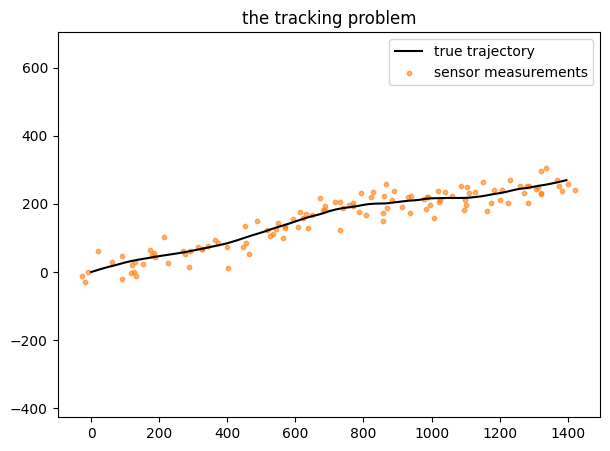

In [2]:
dt = 1.0     # seconds between measurements
T = 120      # number of steps
q = 0.5      # process-noise strength (maneuvering intensity)
r_std = 25.0  # sensor error std [m]

F = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])
H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])
# discretized white-acceleration process noise
G = np.array([[dt**2 / 2, 0], [0, dt**2 / 2], [dt, 0], [0, dt]])
Q = q**2 * (G @ G.T)
R = r_std**2 * np.eye(2)

# simulate the true trajectory and the measurements
x_true = np.zeros((T, 4))
x_true[0] = [0, 0, 12, 4]  # start moving north-east
for t in range(1, T):
    accel = RNG.normal(0, q, size=2)
    x_true[t] = F @ x_true[t - 1] + G @ accel
z = x_true[:, :2] + RNG.normal(0, r_std, size=(T, 2))

plt.figure(figsize=(7, 5))
plt.plot(x_true[:, 0], x_true[:, 1], "k-", label="true trajectory")
plt.scatter(z[:, 0], z[:, 1], s=10, c="C1", alpha=0.6, label="sensor measurements")
plt.axis("equal"); plt.legend(); plt.title("the tracking problem")
plt.show()

## Part 2 - The Kalman filter, from scratch

position RMSE  raw sensor:  35.61 m
position RMSE  Kalman:      16.12 m


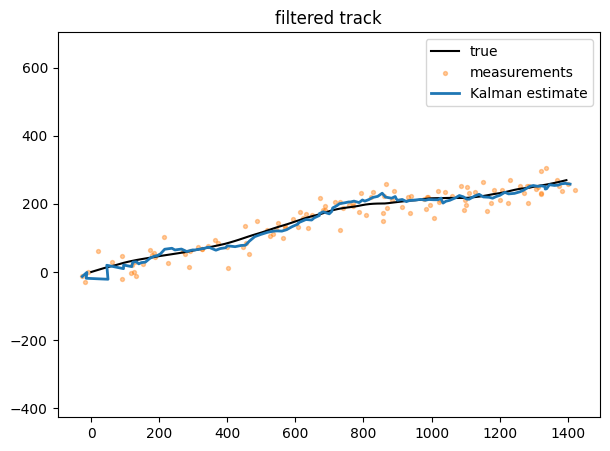

In [3]:
def kalman_filter(zs, F, H, Q, R, x0, P0):
    """Returns filtered means, covariances, innovations and innovation covariances."""
    n = F.shape[0]
    xs, Ps, ys, Ss = [], [], [], []
    x, P = x0.copy(), P0.copy()
    for z in zs:
        # predict
        x = F @ x
        P = F @ P @ F.T + Q
        # update
        y = z - H @ x                      # innovation
        S = H @ P @ H.T + R                # innovation covariance
        K = P @ H.T @ np.linalg.inv(S)     # Kalman gain
        x = x + K @ y
        P = (np.eye(n) - K @ H) @ P
        xs.append(x); Ps.append(P); ys.append(y); Ss.append(S)
    return np.array(xs), np.array(Ps), np.array(ys), np.array(Ss)


x0 = np.array([z[0, 0], z[0, 1], 0, 0])     # start at first measurement, unknown velocity
P0 = np.diag([r_std**2, r_std**2, 100**2, 100**2])  # very uncertain about velocity

xf, Pf, innov, S = kalman_filter(z, F, H, Q, R, x0, P0)

raw_rmse = np.sqrt(np.mean(np.sum((z - x_true[:, :2]) ** 2, axis=1)))
kf_rmse = np.sqrt(np.mean(np.sum((xf[:, :2] - x_true[:, :2]) ** 2, axis=1)))
print(f"position RMSE  raw sensor: {raw_rmse:6.2f} m")
print(f"position RMSE  Kalman:     {kf_rmse:6.2f} m")

plt.figure(figsize=(7, 5))
plt.plot(x_true[:, 0], x_true[:, 1], "k-", label="true")
plt.scatter(z[:, 0], z[:, 1], s=8, c="C1", alpha=0.4, label="measurements")
plt.plot(xf[:, 0], xf[:, 1], "C0-", lw=2, label="Kalman estimate")
plt.axis("equal"); plt.legend(); plt.title("filtered track")
plt.show()

The filter also estimates the **velocity** it never measured - the state model links
position observations across time:

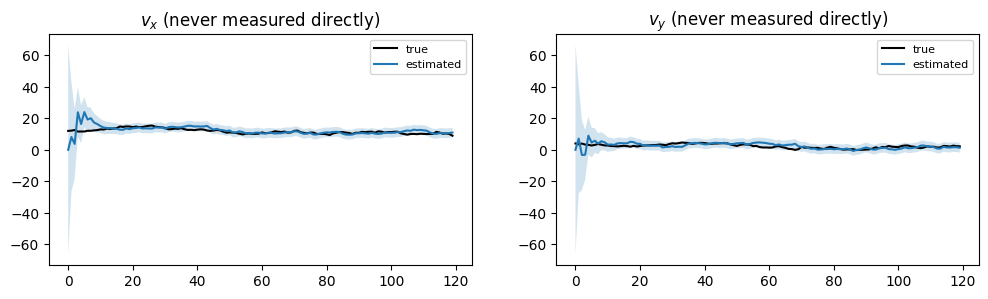

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for i, (ax, name) in enumerate(zip(axes, ["$v_x$", "$v_y$"])):
    ax.plot(x_true[:, 2 + i], "k-", label="true")
    ax.plot(xf[:, 2 + i], "C0-", label="estimated")
    sigma = np.sqrt(Pf[:, 2 + i, 2 + i])
    ax.fill_between(range(T), xf[:, 2 + i] - 2 * sigma, xf[:, 2 + i] + 2 * sigma, alpha=0.2)
    ax.set_title(f"{name} (never measured directly)"); ax.legend(fontsize=8)
plt.show()

## Part 3 - Sensor fusion: add a second, better sensor

A second sensor with 8 m error. Fusion = stack the measurements: $z\in\mathbb{R}^4$,
$H$ stacked, $R$ block-diagonal. Zero new machinery.

In [5]:
r2_std = 8.0
z2 = x_true[:, :2] + RNG.normal(0, r2_std, size=(T, 2))

H_fused = np.vstack([H, H])                                  # both sensors see position
R_fused = np.block([[R, np.zeros((2, 2))],
                    [np.zeros((2, 2)), r2_std**2 * np.eye(2)]])
z_fused = np.hstack([z, z2])

xf2, _, _, _ = kalman_filter(z_fused, F, H_fused, Q, R_fused, x0, P0)
fused_rmse = np.sqrt(np.mean(np.sum((xf2[:, :2] - x_true[:, :2]) ** 2, axis=1)))

xf_only2, _, _, _ = kalman_filter(z2, F, H, Q, r2_std**2 * np.eye(2), x0, P0)
only2_rmse = np.sqrt(np.mean(np.sum((xf_only2[:, :2] - x_true[:, :2]) ** 2, axis=1)))

print(f"RMSE with sensor 1 only (25 m): {kf_rmse:5.2f} m")
print(f"RMSE with sensor 2 only (8 m):  {only2_rmse:5.2f} m")
print(f"RMSE fused:                     {fused_rmse:5.2f} m  <- better than either alone")

RMSE with sensor 1 only (25 m): 16.12 m
RMSE with sensor 2 only (8 m):   5.97 m
RMSE fused:                      5.63 m  <- better than either alone


The filter weighs each sensor by its covariance automatically - the fused estimate beats
the *better* sensor, because even a noisy second opinion carries information.

## Part 4 - Innovation diagnostics: catching a failing sensor

Innovations should be zero-mean with covariance $S_t$. We inject a 100 m bias into
sensor 1 halfway through and watch the normalized innovation squared (NIS) blow past
its $\chi^2_2$ threshold.

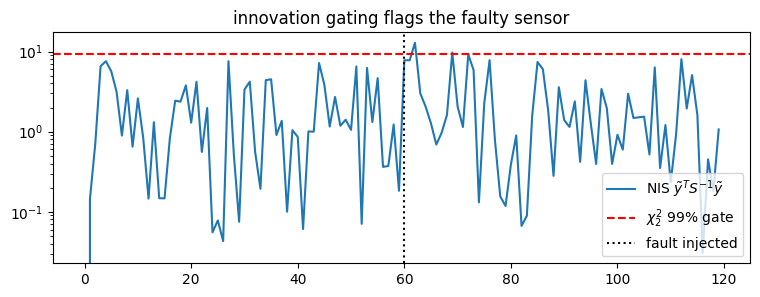

In [6]:
z_broken = z.copy()
z_broken[60:] += np.array([100.0, 0.0])  # sensor 1 develops a bias at t=60

_, _, innov_b, S_b = kalman_filter(z_broken, F, H, Q, R, x0, P0)
nis = np.einsum("ti,tij,tj->t", innov_b, np.linalg.inv(S_b), innov_b)

plt.figure(figsize=(9, 3))
plt.plot(nis, label="NIS $\\tilde y^T S^{-1} \\tilde y$")
plt.axhline(9.21, color="r", ls="--", label="$\\chi^2_2$ 99% gate")
plt.axvline(60, color="k", ls=":", label="fault injected")
plt.yscale("log"); plt.legend(); plt.title("innovation gating flags the faulty sensor")
plt.show()

### TODO exercises

1. Sweep the process noise `q` over [0.05, 0.5, 5]. Small q -> smooth but lags behind
   maneuvers; large q -> follows measurements too closely. Plot the RMSE vs q.
2. Make sensor 2 intermittent (a measurement only every 5 steps): run the fused filter with
   the stacked update when both arrive and the single-sensor update otherwise.
3. Implement the RTS smoother (backward pass) and compare its RMSE to the filter's -
   offline you should always do better.
4. Estimate the bias of the broken sensor online by augmenting the state to
   $(p_x, p_y, v_x, v_y, b_x, b_y)$ with $H$ mapping sensor 1 to position + bias.